# DBGSOM Paper Benchmarks

Reproducible results for the JOSS paper. Run the scripts first:

```bash
uv run python paper_benchmarks/clustering.py
uv run python paper_benchmarks/scaling.py
```


In [63]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("results")

## Clustering — Digits dataset


In [64]:
df_cluster = pd.read_csv(RESULTS / "clustering_digits.csv", index_col="Algorithm").T
df_cluster

Algorithm,DBGSOM,MiniSom,SuSi,torchsom,KMeans
n_prototypes,121,121,121,121,121
Time (s),1.07,3.37,0.14,1.11,1.54
QE,4.84,4.84,5.69,5.95,4.3
TE,0.0257,0.1833,0.0861,0.0889,—
ARI,0.17,0.17,0.25,0.5,0.17
Silhouette,-0.02,0.0,-0.08,-0.04,0.05


## Scaling — training time vs. N


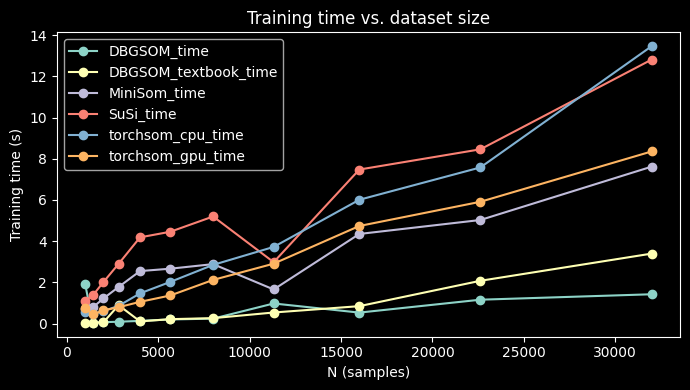

,DBGSOM_time,DBGSOM_n_nodes,DBGSOM_qe,DBGSOM_te,DBGSOM_textbook_time,DBGSOM_textbook_qe,MiniSom_time,MiniSom_n_nodes,MiniSom_qe,SuSi_time,SuSi_n_nodes,SuSi_qe,torchsom_cpu_time,torchsom_cpu_n_nodes,torchsom_cpu_qe,torchsom_gpu_time,torchsom_gpu_n_nodes,torchsom_gpu_qe
N,,,,,,,,,,,,,,,,,,
1000,1.908,36,1.1022,0.0140,0.046,1.0025,0.691,36,1.0012,1.108,36,1.8216,0.552,36,2.3010,0.746,36,2.1714
1414,0.048,39,0.9861,0.0495,0.036,0.9881,0.787,49,0.9826,1.366,49,1.1942,0.467,49,2.5577,0.443,49,2.2543
2000,0.071,57,0.9764,0.0165,0.068,0.9771,1.223,64,0.9785,2.022,64,1.0356,0.609,64,1.9600,0.644,64,2.0683
2828,0.092,74,0.9669,0.0226,0.895,0.9729,1.780,81,0.9733,2.903,81,1.0138,0.864,81,1.8864,0.797,81,1.9903
4000,0.133,102,0.9579,0.0680,0.109,0.9622,2.550,121,0.9633,4.187,121,0.9869,1.468,121,2.0042,1.057,121,1.9675
5656,0.203,107,0.9514,0.0440,0.217,0.9510,2.666,121,0.9657,4.458,121,0.9874,2.025,121,2.0077,1.366,121,2.0782
8000,0.242,117,0.9495,0.0715,0.266,0.9473,2.887,121,0.9718,5.199,121,0.9903,2.851,121,2.0519,2.121,121,2.0150
11313,0.978,72,0.9686,0.0336,0.540,0.9459,1.658,81,0.9798,2.982,81,1.0097,3.722,81,2.0374,2.910,81,1.9777
16000,0.535,150,0.9452,0.0783,0.848,0.9435,4.351,169,0.9688,7.477,169,0.9716,6.010,169,2.0134,4.738,169,2.1662


In [65]:
df_scale = pd.read_csv(RESULTS / "scaling.csv", index_col="N")
times = [
    "DBGSOM_time",
    "DBGSOM_textbook_time",
    "MiniSom_time",
    "SuSi_time",
    "torchsom_cpu_time",
    "torchsom_gpu_time",
]

fig, ax = plt.subplots(figsize=(7, 4))
for col in df_scale[times]:
    ax.plot(df_scale.index, df_scale[col], marker="o", label=col)
    # ax.plot(df_scale["DBGSOM_n_nodes"], df_scale[col], marker="o", label=col)

ax.set_xlabel("N (samples)")
ax.set_ylabel("Training time (s)")
ax.set_title("Training time vs. dataset size")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "scaling_plot.png", dpi=150)
plt.show()
df_scale